# Soft-model overlap: convergence & stability (Reviewer 2, major concern 1)

Answers whether the soft model's unphysical central packing (phi>1) is a numerical artifact or intrinsic. Produces the 3-panel figure `soft_overlap_analysis.png` (paper Fig. 5) in the repository plotting style (MODE_COLORS, seaborn, dpi=300).

- **(a)** phi_center vs colony radius for four step-sizes (via c_CFL) at fixed stiffness: the soft curves collapse => converged in dt, not under-resolved.
- **(b)** phi_center vs stiffness k_cc: decreases toward the rigid (hard) limit.
- **(c)** measured critical CFL factor vs k_cc: stable step-size scales as k_cc^-0.96, confirming the derived limit dt proportional to zeta/k_cc (paper Eq. 11).

Reads the pre-computed CSVs in this folder (raw VTK is large and not committed); see README.md.

saved; stability slope = -0.96


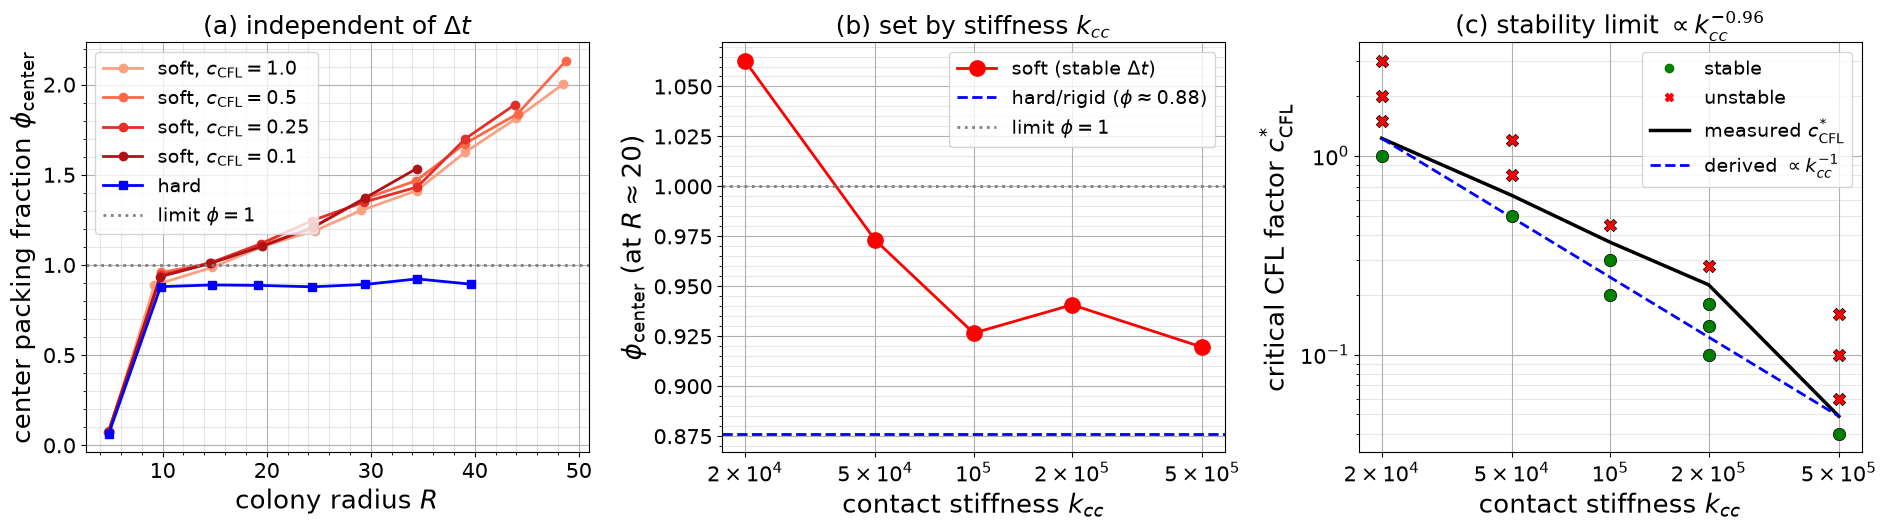

In [1]:
import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, NullLocator

SPD = "."
MODE_COLORS = {"hard": "blue", "soft": "red", "Weady et al.": "black"}
FS_L, FS_T, FS_LG, FS_TT = 19, 15, 14, 18

KTICKS = [2e4, 5e4, 1e5, 2e5, 5e5]
KLABS = [r"$2\times10^4$", r"$5\times10^4$", r"$10^5$", r"$2\times10^5$", r"$5\times10^5$"]

def grid(ax):
    ax.grid(which="major"); ax.grid(which="minor", alpha=0.3); ax.minorticks_on()
    ax.tick_params(axis='x', labelsize=FS_T); ax.tick_params(axis='y', labelsize=FS_T)

def kcc_ticks(ax):
    ax.xaxis.set_major_locator(FixedLocator(KTICKS))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xticklabels(KLABS)

fig, axs = plt.subplots(1, 3, figsize=(19, 5.4))

# (a) phi vs R collapse across dt
conv = pd.read_csv(SPD + "/conv_curves.csv"); ax = axs[0]
soft = conv[conv["mode"] == "soft"]; cfls = sorted(soft["cfl"].unique(), reverse=True)
reds = sns.color_palette("Reds", n_colors=len(cfls) + 1)[1:]
for c, col in zip(cfls, reds):
    g = soft[soft["cfl"] == c].sort_values("R")
    ax.plot(g["R"], g["phi_center"], marker="o", ms=6, lw=2, color=col,
            label=fr"soft, $c_{{\rm CFL}}={c}$")
h = conv[conv["mode"] == "hard"].sort_values("R")
ax.plot(h["R"], h["phi_center"], marker="s", ms=6, lw=2, color=MODE_COLORS["hard"], label="hard")
ax.axhline(1.0, ls=":", color="grey", lw=2, label=r"limit $\phi=1$")
ax.set_xlabel(r"colony radius $R$", fontsize=FS_L)
ax.set_ylabel(r"center packing fraction $\phi_{\mathrm{center}}$", fontsize=FS_L)
ax.set_title(r"(a) independent of $\Delta t$", fontsize=FS_TT)
ax.legend(fontsize=FS_LG, loc="upper left"); grid(ax)

# (b) phi vs kcc toward rigid limit
kp = pd.read_csv(SPD + "/kcc_phi.csv").sort_values("kcc"); ax = axs[1]
s = kp[kp["mode"] == "soft"]; hphi = kp[kp["mode"] == "hard"]["phi_center"].iloc[0]
ax.plot(s["kcc"], s["phi_center"], marker="o", ms=11, lw=2, color=MODE_COLORS["soft"],
        label=r"soft (stable $\Delta t$)")
ax.axhline(hphi, ls="--", color=MODE_COLORS["hard"], lw=2, label=fr"hard/rigid ($\phi\approx{hphi:.2f}$)")
ax.axhline(1.0, ls=":", color="grey", lw=2, label=r"limit $\phi=1$")
ax.set_xscale("log"); ax.set_xlabel(r"contact stiffness $k_{cc}$", fontsize=FS_L)
ax.set_ylabel(r"$\phi_{\mathrm{center}}$ (at $R\approx20$)", fontsize=FS_L)
ax.set_title(r"(b) set by stiffness $k_{cc}$", fontsize=FS_TT)
ax.legend(fontsize=FS_LG); grid(ax); kcc_ticks(ax)

# (c) stability threshold cfl* vs kcc
rows = []
for ln in open(SPD + "/stab_results.txt"):
    m = re.match(r"(\S+)\s+(\S+)\s+warns=(\d+)", ln)
    if m: rows.append((float(m.group(1)), float(m.group(2)), int(m.group(3))))
from collections import defaultdict
st, un = defaultdict(list), defaultdict(list)
for k, c, w in rows: (st if w == 0 else un)[k].append(c)
kk, cs = [], []
for k in sorted(set(k for k, _, _ in rows)):
    if st[k] and un[k]: kk.append(k); cs.append(np.sqrt(max(st[k]) * min(un[k])))
kk, cs = np.array(kk), np.array(cs)
slope, inter = np.polyfit(np.log(kk), np.log(cs), 1)
ax = axs[2]
for k, c, w in rows:
    ax.scatter(k, c, marker=("o" if w == 0 else "X"), s=80, zorder=3,
               color=("green" if w == 0 else MODE_COLORS["soft"]), edgecolor="k", linewidth=0.5)
ax.plot(kk, cs, "-", color="k", lw=2.5)
kf = np.logspace(np.log10(kk.min()), np.log10(kk.max()), 50)
ax.plot(kf, cs[0] * (kf / kk[0]) ** (-1.0), "--", color="blue", lw=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"contact stiffness $k_{cc}$", fontsize=FS_L)
ax.set_ylabel(r"critical CFL factor $c_{\rm CFL}^{*}$", fontsize=FS_L)
ax.set_title(fr"(c) stability limit $\propto k_{{cc}}^{{{slope:.2f}}}$", fontsize=FS_TT)
hd = [Line2D([], [], marker="o", color="green", ls="", label="stable"),
      Line2D([], [], marker="X", color=MODE_COLORS["soft"], ls="", label="unstable"),
      Line2D([], [], color="k", lw=2.5, label=r"measured $c_{\rm CFL}^{*}$"),
      Line2D([], [], color="blue", ls="--", lw=2, label=r"derived $\propto k_{cc}^{-1}$")]
ax.legend(handles=hd, fontsize=FS_LG); grid(ax); kcc_ticks(ax)

plt.tight_layout()
fig.savefig(SPD + "/soft_overlap_analysis.png", dpi=300, bbox_inches="tight")
print("saved; stability slope =", round(slope, 2))
